### Download Oracle stock data

In [4]:
import pandas as pd
df = pd.read_excel(r"C:\shampa\Courses\Projects\StockMarketAnalysis\oracle.xlsx")
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily return
0,2026-04-20,176.81,177.76,173.51,177.58,177.58,22243500,0.000000
1,2026-04-17,182.93,184.50,173.36,175.06,175.06,45282600,-0.014191
2,2026-04-16,176.42,180.27,173.80,178.34,178.34,46997300,0.018736
3,2026-04-15,166.89,172.56,166.21,169.81,169.81,43010800,-0.047830
4,2026-04-14,167.93,169.40,161.56,163.00,163.00,59779800,-0.040104
...,...,...,...,...,...,...,...,...
250,2025-04-25,137.49,139.00,136.76,138.49,137.11,5476400,-0.011820
251,2025-04-24,132.51,137.86,132.00,137.51,136.14,7305900,-0.007075
252,2025-04-23,134.91,135.87,130.99,131.40,130.09,9528900,-0.044440
253,2025-04-22,124.50,127.99,123.39,127.24,125.98,11233700,-0.031594


### Calculate Daily Return

In [16]:
import numpy as np
log_return = df["log return"]= np.log(1+df["Daily return"]).shift(1)
df.dropna()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily return,log return
1,2026-04-17,182.93,184.50,173.36,175.06,175.06,45282600,-0.014191,0.000000
2,2026-04-16,176.42,180.27,173.80,178.34,178.34,46997300,0.018736,-0.014292
3,2026-04-15,166.89,172.56,166.21,169.81,169.81,43010800,-0.047830,0.018563
4,2026-04-14,167.93,169.40,161.56,163.00,163.00,59779800,-0.040104,-0.049012
5,2026-04-13,139.77,155.91,139.72,155.62,155.62,49997700,-0.045276,-0.040930
...,...,...,...,...,...,...,...,...,...
250,2025-04-25,137.49,139.00,136.76,138.49,137.11,5476400,-0.011820,-0.004602
251,2025-04-24,132.51,137.86,132.00,137.51,136.14,7305900,-0.007075,-0.011890
252,2025-04-23,134.91,135.87,130.99,131.40,130.09,9528900,-0.044440,-0.007100
253,2025-04-22,124.50,127.99,123.39,127.24,125.98,11233700,-0.031594,-0.045457


### Calculate volatility
 
 ***used log(1+r) because it gives value closer to r
 ✅ Correct: ln(1.08)=0.07696
❌ Wrong: ln(0.08)=−2.52
beacause the negative number makes no sense for a positive return.***

In [33]:
volatility = log_return.std()*100
annual_scaled_volatility = volatility*np.sqrt(252)*100
rollilng_volatility_fifteen = log_return.rolling(window = 15).std().shift(14).dropna()*100

print(f"volatility:{volatility}")
print(f"annual_scaled_volatility:{annual_scaled_volatility}")
print(f"rollilng_volatility_fifteen:{rollilng_volatility_fifteen}")


volatility:3.652715053566965
annual_scaled_volatility:5798.505385152098
rollilng_volatility_fifteen:29     3.834924
30     3.987290
31     4.030558
32     4.054144
33     4.045137
         ...   
250    1.443779
251    1.410090
252    1.545035
253    1.491740
254    1.648370
Name: Daily return, Length: 226, dtype: float64


### Install libraries

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn hmmlearn yfinance plotly streamlit

  Obtaining dependency information for hmmlearn from https://files.pythonhosted.org/packages/92/57/24bd2359bf0f2a2514f7b53f0bca562f912ac4751e415756b9138970c5aa/hmmlearn-0.3.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/90/ad/cba91b3bcf04073e4d1655a5c1710ef3f457f56f7d1b79dcc3d72f4dd912/plotly-6.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/d8/1a/3ca2293d8552bacea3e67e9600d2d1df7df4a325059769ad83d91c279595/streamlit-1.57.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=1.15.1 from https://files.pythonhosted.org/packages/d0/69/f24d3d1c38ad69e256138b4ec2452a8c7cf66be49dc214771ae99dd4f0a0/narwhals-2.20.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/ce/63/5dacc8d8306c715088b897a479e551bc0779fd2f0f26c97fec5e36542b


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Create Main Dataset

In [21]:
import yfinance as yf
import pandas as pd

def load_data():

    df = yf.download(
        "ORCL",
        start="2018-01-01",
        end="2026-01-01"
    )

    df.columns = df.columns.get_level_values(0)

    df.reset_index(inplace=True)

    return df
OracleData = load_data()
OracleData
# print(OracleData.columns)

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2018-01-02,41.107628,42.139064,40.702103,41.936303,25380000
1,2018-01-03,42.059723,42.377089,41.821698,41.901040,24165000
2,2018-01-04,42.474060,42.482874,42.068539,42.306563,19815100
3,2018-01-05,42.729710,42.870761,42.562209,42.685628,14496400
4,2018-01-08,43.179310,43.258651,42.262476,42.579842,15075000
...,...,...,...,...,...,...
2006,2025-12-24,196.283798,197.068966,193.232542,193.809001,9282700
2007,2025-12-26,196.780746,199.146200,194.912224,196.850311,11262000
2008,2025-12-29,194.186691,197.297564,191.463421,192.974141,14748100
2009,2025-12-30,196.005508,197.168361,194.514670,194.862523,14197400


### Feature Engineering

In [16]:
import pandas as pd
import numpy as np

def create_features(df):

    # Daily returns
    df['Returns'] = df['Close'].pct_change()

    # Rolling volatility
    df['Volatility_20'] = (
        df['Returns']
        .rolling(20)
        .std()
    )

    # Momentum
    df['Momentum_20'] = (
        df['Close']
        .pct_change(20)
    )

    # Moving average ratio
    ma20 = df['Close'].rolling(20).mean()
    ma100 = df['Close'].rolling(100).mean()

    df['MA_Ratio'] = ma20 / ma100

    # Drawdown
    df['Rolling_Max'] = df['Close'].cummax()

    df['Drawdown'] = (
        df['Close'] / df['Rolling_Max']
    ) - 1

    df.dropna(inplace=True)

    return df

### Build KMeans Regime Detector

In [45]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def detect_regimes(df):

    features = df[
        [
            'Returns',
            'Volatility_20',
            'Momentum_20',
            'Drawdown'
        ]
    ]

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(features)

    model = KMeans(
        n_clusters=3,
        random_state=42
    )

    df['Regime'] = model.fit_predict(X_scaled)
    # print(f"these are regime values:\n{df['Regime']}")
    print(
    df.groupby('Regime')[
        [
            'Returns',
            'Volatility_20',
            'Momentum_20',
            'Drawdown'
        ]
    ].mean()
)

    return df

### Visualization

In [18]:
import matplotlib.pyplot as plt

def plot_regimes(df):

    plt.figure(figsize=(15,7))

    plt.scatter(
        df['Date'],
        df['Close'],
        c=df['Regime'],
        cmap='viridis'
    )

    plt.plot(
        df['Date'],
        df['Close'],
        alpha=0.3
    )

    plt.title('Oracle Market Regimes')

    plt.xlabel('Date')
    plt.ylabel('Price')

    plt.show()

### Risk Analysis

In [19]:
def regime_statistics(df):

    stats = df.groupby('Regime')[
        ['Returns', 'Volatility_20']
    ].agg(
        ['mean', 'std', 'min', 'max']
    )

    return stats

[*********************100%***********************]  1 of 1 completed


Price    Returns  Volatility_20  Momentum_20  Drawdown
Regime                                                
0       0.001847       0.013864     0.030383 -0.064765
1      -0.007006       0.025375    -0.074245 -0.237029
2       0.014515       0.040844     0.177938 -0.075275
Price    Returns                               Volatility_20            \
            mean       std       min       max          mean       std   
Regime                                                                   
0       0.001847  0.013500 -0.065308  0.071664      0.013864  0.004885   
1      -0.007006  0.027501 -0.137908  0.122008      0.025375  0.010215   
2       0.014515  0.044723 -0.062346  0.359488      0.040844  0.020810   

Price                       
             min       max  
Regime                      
0       0.004591  0.035332  
1       0.011217  0.074157  
2       0.017999  0.089702  


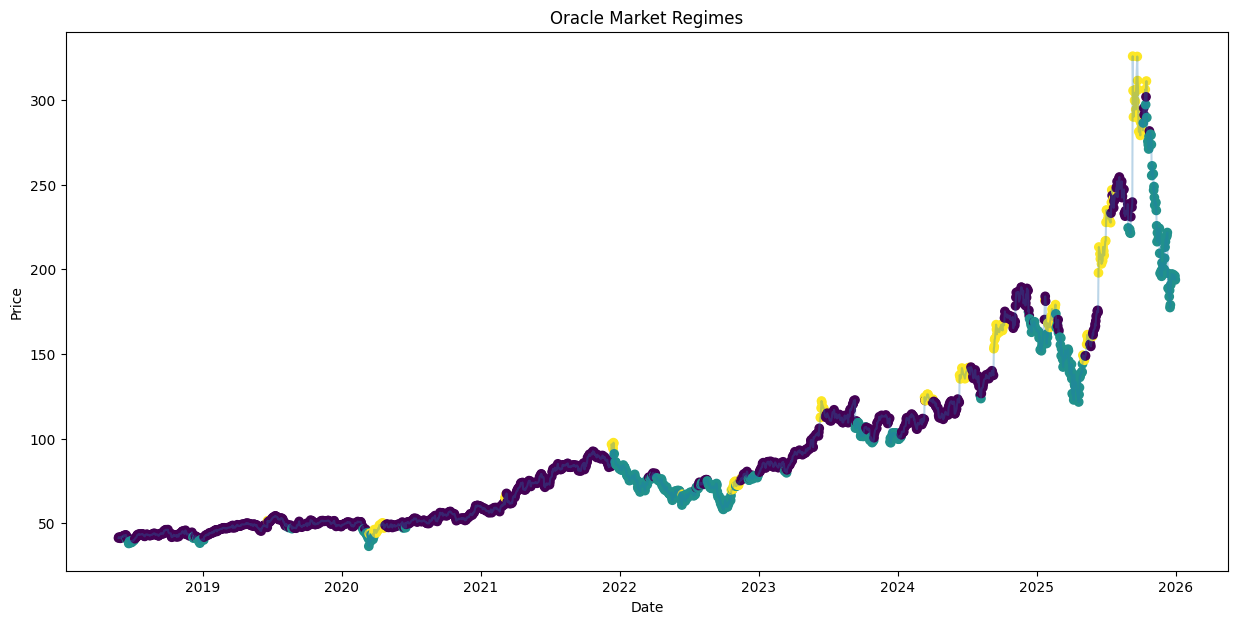

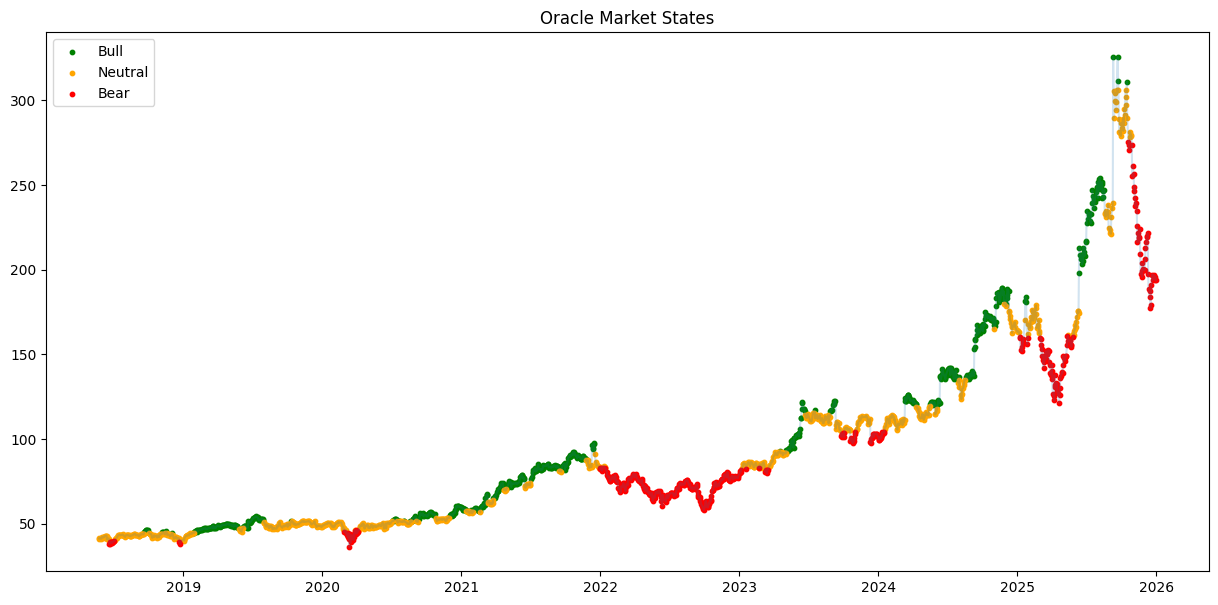

In [46]:
def main():

    df = load_data()

    df = create_features(df)

    df = detect_regimes(df)

    print(regime_statistics(df))

    plot_regimes(df)
    df
    def classify_market(drawdown):
    
        if drawdown > -0.05:
            return 'Bull'
    
        elif drawdown > -0.15:
            return 'Neutral'
    
        else:
            return 'Bear'
    df['Market_State'] = df['Drawdown'].apply(classify_market)
    import matplotlib.pyplot as plt

    colors = {
        'Bull': 'green',
        'Neutral': 'orange',
        'Bear': 'red'
    }
    
    plt.figure(figsize=(15,7))
    
    for state in colors:
    
        subset = df[df['Market_State'] == state]
    
        plt.scatter(
            subset['Date'],
            subset['Close'],
            color=colors[state],
            label=state,
            s=10
        )
    
    plt.plot(df['Date'], df['Close'], alpha=0.2)
    
    plt.legend()
    
    plt.title("Oracle Market States")
    
    plt.show()
   
if __name__ == "__main__":
    main()